# Install dependencies and configure the environment

In [1]:
%pip -qqq install miditoolkit kagglehub scikit-learn torch pandarallel

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.6 MB/s eta 0:00:00


In [2]:
# Dependencies
from __future__ import annotations
from collections import OrderedDict

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

from bisect import bisect_right
import copy
import glob
import hashlib
import time
import json
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
from miditoolkit import MidiFile
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

In [3]:
from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [4]:
# Check if PyTorch can access an NVIDIA GPU through CUDA
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# Import Kaggle dataset


In [5]:
# Download dataset
directory = kagglehub.dataset_download(
  "blanderbuss/midi-classic-music"
)

Using Colab cache for faster access to the 'midi-classic-music' dataset.


## Extract MIDI files

Recursively filter for Bach, Beethoven, Chopin, and Mozart MIDI files only


In [6]:
# Search for MIDI (.mid) files belonging to 4 composers
def read_midi_files(composers):
  midi_files = []
  for composer in composers:
    midi_filenames = sorted(
            set(
                glob.glob(
                    f"{directory}/midiclassics/{composer}/**/*.mid",
                    recursive=True)))

    print(f'Found {len(midi_filenames)} .mid files for {composer}')

    midi_files += [{
        'composer': composer,
        'filename': filename
    } for filename in midi_filenames]

  df = pd.DataFrame(midi_files)
  return df

df = read_midi_files(['Bach', 'Beethoven', 'Chopin', 'Mozart'])

def file_sha1(filename):
    hasher = hashlib.sha1()
    with open(filename, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

df["content_hash"] = df["filename"].apply(file_sha1)

conflicts = df.groupby("content_hash")["composer"].nunique()
if (conflicts > 1).any():
    raise ValueError("Identical MIDI files have different composer labels.")

duplicates_removed = df.duplicated("content_hash").sum()
df = df.drop_duplicates("content_hash").reset_index(drop=True)

print("Duplicate MIDI files removed:", duplicates_removed)

df

Found 925 .mid files for Bach
Found 212 .mid files for Beethoven
Found 136 .mid files for Chopin
Found 257 .mid files for Mozart
Duplicate MIDI files removed: 20


,composer,filename,content_hash
0,Bach,/kaggle/input/midi-classic-music/midiclassics/...,e446e98103f7ec72f2c5b460872820382d6b5007
1,Bach,/kaggle/input/midi-classic-music/midiclassics/...,a621bc47a2dbe378166f6fbc40b449a9b12e3e87
2,Bach,/kaggle/input/midi-classic-music/midiclassics/...,d9fb174748d091ee217073189ebc2335117a9c15
3,Bach,/kaggle/input/midi-classic-music/midiclassics/...,32a8b534b984c883a6f981bde0c3a3585807f9cb
4,Bach,/kaggle/input/midi-classic-music/midiclassics/...,64e021019b49423494aca373ae1b0634a2d0c1e5
...,...,...,...
1505,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,dcb1b02523bd3ebe383c8ad0ce144a6e2fd0ecc9
1506,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,ec2057838f086123fbdf7a3d6e3fdcea41491d6c
1507,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,58ec5eb3e56a270cbb5d10f0d0aa0565ca37b465
1508,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,2005cf54eccf37620a524506c4bcf7af8eb7392e


# Data pre-processing and feature extraction

The downloaded `midiclassics` dataset contains composer-specific directories, including nested subdirectories. MIDI files for Bach, Beethoven, Chopin, and Mozart are located recursively and exact content duplicates are removed.

Each MIDI file is converted into an ordered sequence of note events. The extracted features are:

- pitch
- pitch class
- duration in beats
- normalized velocity
- onset spacing in beats
- MIDI instrument program
- tempo
- time-signature numerator
- time-signature denominator

Source-level training, validation, and test splits are created later using stratification by composer.


### Feature extraction research context

Symbolic-music models commonly represent a score as an ordered sequence of note events. MusicBERT’s OctupleMIDI representation demonstrates the usefulness of metrical position, instrument, pitch, duration, velocity, tempo, and time signature for symbolic-music understanding (Zeng et al., 2021). Inspired by this event-based representation, this notebook extracts pitch, pitch class, duration, velocity, onset spacing, instrument program, tempo, and meter.

MIDI files are parsed, and online pitch transposition from −2 to +2 semitones is applied only to training crops. Validation and test sequences remain unchanged. Controlled transformations of symbolic MIDI have also been explored in prior work (McLeod et al., 2020). Augmentation is applied only after the source-level split, and all variants sharing the same content-based `source_id` remain in the training partition to prevent data leakage.

#### APA 7 references

McLeod, A., Owers, J., & Yoshii, K. (2020). The MIDI degradation toolkit:
Symbolic music augmentation and correction. arXiv.
https://doi.org/10.48550/arXiv.2010.00059

Zeng, M., Tan, X., Wang, R., Ju, Z., Qin, T., & Liu, T.-Y. (2021).
MusicBERT: Symbolic music understanding with large-scale pre-training.
In Findings of the Association for Computational Linguistics:
ACL-IJCNLP 2021 (pp. 791–800).
https://doi.org/10.18653/v1/2021.findings-acl.70


In [7]:
# Parse source MIDI files, extract event-level note features, and build a
# leakage-safe dataset. Training-time augmentation is applied only by the data loader.
def stable_source_id(path):
    return file_sha1(path)[:16]


def _active_tempo(tick: int, tempo_ticks: list[int], tempo_values: list[float]) -> float:
    """Return the most recent tempo at a note onset."""
    idx = max(0, bisect_right(tempo_ticks, tick) - 1)
    return tempo_values[idx]


def _active_meter_index(tick: int, meter_ticks: list[int]) -> int:
    return max(0, bisect_right(meter_ticks, tick) - 1)


def extract_event_features(midi_path: str | Path) -> dict:
    """Convert a MIDI file into chronological, texture-aware note-event features."""
    midi = MidiFile(str(midi_path))
    tpq = max(int(midi.ticks_per_beat), 1)

    tempo_changes = sorted(midi.tempo_changes, key=lambda x: x.time)
    tempo_ticks = [int(x.time) for x in tempo_changes] or [0]
    tempo_values = [float(x.tempo) for x in tempo_changes] or [120.0]

    meter_changes = sorted(midi.time_signature_changes, key=lambda x: x.time)
    meter_ticks = [int(x.time) for x in meter_changes] or [0]
    numerators = [int(x.numerator) for x in meter_changes] or [4]
    denominators = [int(x.denominator) for x in meter_changes] or [4]

    raw_events = []
    for instrument in midi.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            raw_events.append((
                int(note.start), int(note.end), int(note.pitch),
                int(note.velocity), int(instrument.program),
            ))

    raw_events.sort(key=lambda event: (event[0], event[2], event[1]))
    features = []
    active_end_ticks = []
    previous_start = raw_events[0][0] if raw_events else 0
    previous_pitch = raw_events[0][2] if raw_events else 0
    event_index = 0

    while event_index < len(raw_events):
        start = raw_events[event_index][0]
        onset_events = []
        while event_index < len(raw_events) and raw_events[event_index][0] == start:
            onset_events.append(raw_events[event_index])
            event_index += 1

        active_end_ticks = [end for end in active_end_ticks if end > start]
        pitches = [event[2] for event in onset_events]
        chord_size = len(onset_events)
        chord_span = max(pitches) - min(pitches)
        meter_index = _active_meter_index(start, meter_ticks)
        numerator = numerators[meter_index]
        denominator = denominators[meter_index]
        ticks_per_measure = max(tpq * 4 * numerator / denominator, 1.0)
        measure_phase = ((start - meter_ticks[meter_index]) % ticks_per_measure) / ticks_per_measure
        onset_delta_beats = max(start - previous_start, 0) / tpq

        for chord_rank, (note_start, end, pitch, velocity, program) in enumerate(onset_events):
            duration_beats = max(end - note_start, 1) / tpq
            pitch_interval = pitch - previous_pitch if features else 0
            rank_fraction = chord_rank / max(chord_size - 1, 1)

            features.append({
                "pitch": pitch,
                "pitch_class": pitch % 12,
                "pitch_interval": pitch_interval,
                "absolute_pitch_interval": abs(pitch_interval),
                "log_duration_beats": np.log1p(duration_beats),
                "velocity": velocity / 127.0,
                "log_onset_delta_beats": np.log1p(onset_delta_beats),
                "beat_position": measure_phase,
                "beat_phase_sin": np.sin(2.0 * np.pi * measure_phase),
                "beat_phase_cos": np.cos(2.0 * np.pi * measure_phase),
                "chord_size": chord_size,
                "chord_span": chord_span,
                "active_note_count": len(active_end_ticks),
                "chord_rank": rank_fraction,
                "program": program,
                "tempo_bpm": _active_tempo(note_start, tempo_ticks, tempo_values),
                "time_signature_numerator": numerator,
                "time_signature_denominator": denominator,
            })
            previous_pitch = pitch

        active_end_ticks.extend(event[1] for event in onset_events)
        previous_start = start

    return {
        "event_features": features,
        "sequence_length": len(features),
        "ticks_per_beat": tpq,
    }


def process_single_midi_row(row):
    try:
        midi_path = Path(row.filename)
        source_id = stable_source_id(row.filename)

        extracted = extract_event_features(midi_path)

        return {
            "composer": row.composer,
            "source_id": source_id,
            "augmentation": "original",
            "pitch_shift": 0,
            "tempo_factor": 1.0,
            "midi_path": str(midi_path),
            **extracted,
        }
    except Exception as exc:
        print(f"Skipped {row.filename}: {exc}")
        return None


def build_preprocessed_dataset(source_df: pd.DataFrame) -> pd.DataFrame:
    """Read source MIDI files and extract original event sequences using parallel_apply."""
    results = source_df.parallel_apply(process_single_midi_row, axis=1)
    valid_results = results.dropna()
    if valid_results.empty:
        return pd.DataFrame()

    return pd.DataFrame(valid_results.tolist())

In [8]:
# Preprocess original MIDI files only.
# Source-level splitting and training-only augmentation are performed later to
# prevent augmented versions of the same piece appearing in multiple splits.

processed_df = build_preprocessed_dataset(df)

print(f"Created {len(processed_df):,} original sequences.")
display(
    processed_df[
        ["composer", "source_id", "augmentation", "sequence_length", "midi_path"]
    ].head()
)
print("\nClass counts:")
display(processed_df["composer"].value_counts())

Skipped /kaggle/input/midi-classic-music/midiclassics/Beethoven/Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
Skipped /kaggle/input/midi-classic-music/midiclassics/Mozart/Piano Sonatas/Nueva carpeta/K281 Piano Sonata n03 3mov.mid: Could not decode key with 2 flats and mode 2
Created 1,508 original sequences.


,composer,source_id,augmentation,sequence_length,midi_path
0,Bach,e446e98103f7ec72,original,793,/kaggle/input/midi-classic-music/midiclassics/...
1,Bach,a621bc47a2dbe378,original,524,/kaggle/input/midi-classic-music/midiclassics/...
2,Bach,d9fb174748d091ee,original,428,/kaggle/input/midi-classic-music/midiclassics/...
3,Bach,32a8b534b984c883,original,418,/kaggle/input/midi-classic-music/midiclassics/...
4,Bach,64e021019b494234,original,622,/kaggle/input/midi-classic-music/midiclassics/...



Class counts:


,count
composer,
Bach,915
Mozart,254
Beethoven,207
Chopin,132


## Dataset formatting, leakage-safe splitting, and NumPy serialization

This section converts the event dictionaries in `processed_df` into variable-length numerical event arrays. Splits are performed at the unique original MIDI-source level using a content-based `source_id`, with stratification by composer. Exact duplicate MIDI files are removed before splitting. Online augmentation is applied only to training crops, while validation and test data remain unchanged.

Generated artifacts:

- `X_train`, `X_val`, `X_test`: lists of event arrays with shape `(events, features)`
- `y_train`, `y_val`, `y_test`: integer composer labels
- compressed `.npz` split files, a label map, a feature specification, and CSV manifests

Fixed-size crops and valid-event masks are created later by the data loader.

In [9]:
# Reproducible split configuration.
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

# Base feature order used by preprocessing and model-specific data loaders.
# Meter is represented by derived phase features rather than raw time-signature fields.
FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_position",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
    "chord_rank",
]

SERIALIZED_DIR = Path("serialized_dataset")
SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)


def validate_processed_dataframe(dataframe: pd.DataFrame) -> None:
    """Check that preprocessing created the columns required below."""
    required = {"composer", "source_id", "augmentation", "event_features"}
    missing = required.difference(dataframe.columns)
    if missing:
        raise ValueError(
            "processed_df is missing required columns: " + ", ".join(sorted(missing))
        )
    if dataframe.empty:
        raise ValueError("processed_df is empty; run the preprocessing cell first.")


def make_source_level_splits(dataframe: pd.DataFrame):
    """Split unique original sources with composer stratification."""
    source_table = (
        dataframe[["source_id", "composer"]]
        .drop_duplicates()
        .sort_values(["composer", "source_id"])
        .reset_index(drop=True)
    )

    conflicts = source_table.groupby("source_id")["composer"].nunique()
    if (conflicts > 1).any():
        bad_ids = conflicts[conflicts > 1].index.tolist()[:5]
        raise ValueError(f"Some source IDs have multiple composer labels: {bad_ids}")

    class_counts = source_table["composer"].value_counts()
    if (class_counts < 3).any():
        raise ValueError(
            "Each composer needs at least three original files for train/validation/test "
            f"splitting. Counts: {class_counts.to_dict()}"
        )

    train_sources, temp_sources = train_test_split(
        source_table,
        train_size=TRAIN_SIZE,
        random_state=RANDOM_STATE,
        stratify=source_table["composer"],
    )

    relative_test_size = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)
    val_sources, test_sources = train_test_split(
        temp_sources,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
        stratify=temp_sources["composer"],
    )

    return train_sources, val_sources, test_sources


def select_rows_for_split(
    dataframe: pd.DataFrame,
    source_table: pd.DataFrame,
) -> pd.DataFrame:
    """Select original source rows for one leakage-safe partition."""
    return (
        dataframe[dataframe["source_id"].isin(source_table["source_id"])]
        .sort_values(["composer", "source_id"])
        .reset_index(drop=True)
    )


def encode_and_format(split_df: pd.DataFrame, label_to_index: dict):
    """Create unnormalized event arrays and integer labels for one split."""
    sequences = []
    for events_list in split_df["event_features"].tolist():
        sequence = [
            [event.get(feature_name, 0.0) for feature_name in FEATURE_NAMES]
            for event in events_list
        ]
        sequences.append(
            np.asarray(sequence, dtype=np.float32).reshape(-1, len(FEATURE_NAMES))
        )

    encoded = split_df["composer"].map(label_to_index)
    if encoded.isna().any():
        unknown = split_df.loc[encoded.isna(), "composer"].unique().tolist()
        raise ValueError(f"Unknown composer labels: {unknown}")

    return sequences, encoded.to_numpy(dtype=np.int64)


def fit_feature_normalizer(train_sequences):
    """Fit robust feature statistics using training events only."""
    nonempty_sequences = [sequence for sequence in train_sequences if len(sequence)]
    if not nonempty_sequences:
        raise ValueError("Training split has no valid note events.")

    train_events = np.concatenate(nonempty_sequences, axis=0)
    center = np.median(train_events, axis=0).astype(np.float32)
    lower = np.percentile(train_events, 25, axis=0)
    upper = np.percentile(train_events, 75, axis=0)
    scale = np.maximum(upper - lower, 0.01).astype(np.float32)
    return center, scale


def save_split(name, X, y, manifest: pd.DataFrame):
    """Serialize arrays as compressed NPZ and metadata as CSV."""
    np.savez_compressed(
        SERIALIZED_DIR / f"{name}.npz",
        X_sequences=np.array(X, dtype=object),
        y=y,
        feature_names=np.asarray(FEATURE_NAMES),
    )
    manifest_columns = [
        column for column in
        ["composer", "source_id", "augmentation", "midi_path", "sequence_length"]
        if column in manifest.columns
    ]
    manifest[manifest_columns].to_csv(
        SERIALIZED_DIR / f"{name}_manifest.csv", index=False
    )

In [10]:
# Retain a complete base tensor so experimental features stay available for future work.
# Each model receives its validated subset in make_loaders.
FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_position",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
    "chord_rank",
]
# CNN_FEATURE_NAMES and LSTM_FEATURE_NAMES are subsets of FEATURE_NAMES that were selected by feature ablation experiments in the Agentic Feature Selection section of this notebook.
CNN_FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
]
LSTM_FEATURE_NAMES = [
    "pitch",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "log_onset_delta_beats",
    "beat_position",
    "chord_span",
    "active_note_count",
    "chord_rank",
]
MODEL_FEATURE_NAMES = {
    "All": FEATURE_NAMES,
    "CNN": CNN_FEATURE_NAMES,
    "LSTM": LSTM_FEATURE_NAMES,
}

print("Base features:", FEATURE_NAMES)
for model_name, feature_names in MODEL_FEATURE_NAMES.items():
    print(f"{model_name} features ({len(feature_names)}):", feature_names)

Base features: ['pitch', 'pitch_class', 'pitch_interval', 'absolute_pitch_interval', 'log_duration_beats', 'velocity', 'log_onset_delta_beats', 'beat_position', 'beat_phase_sin', 'beat_phase_cos', 'chord_size', 'chord_span', 'active_note_count', 'chord_rank']
All features (14): ['pitch', 'pitch_class', 'pitch_interval', 'absolute_pitch_interval', 'log_duration_beats', 'velocity', 'log_onset_delta_beats', 'beat_position', 'beat_phase_sin', 'beat_phase_cos', 'chord_size', 'chord_span', 'active_note_count', 'chord_rank']
CNN features (12): ['pitch', 'pitch_class', 'pitch_interval', 'absolute_pitch_interval', 'log_duration_beats', 'velocity', 'log_onset_delta_beats', 'beat_phase_sin', 'beat_phase_cos', 'chord_size', 'chord_span', 'active_note_count']
LSTM features (9): ['pitch', 'pitch_interval', 'absolute_pitch_interval', 'log_duration_beats', 'log_onset_delta_beats', 'beat_position', 'chord_span', 'active_note_count', 'chord_rank']


In [11]:
# Create leakage-safe source-level splits, encode original source sequences into
# variable-length event arrays, and save the data and metadata. Class balance is handled by
# the source-balanced training sampler, not duplicate offline variants.
def calculate_total_nbytes(list_of_arrays):
    return sum(array.nbytes for array in list_of_arrays)


validate_processed_dataframe(processed_df)
train_sources, val_sources, test_sources = make_source_level_splits(processed_df)

train_df = select_rows_for_split(processed_df, train_sources)
val_df = select_rows_for_split(processed_df, val_sources)
test_df = select_rows_for_split(processed_df, test_sources)

assert set(train_df["source_id"]).isdisjoint(val_df["source_id"])
assert set(train_df["source_id"]).isdisjoint(test_df["source_id"])
assert set(val_df["source_id"]).isdisjoint(test_df["source_id"])
assert train_df["augmentation"].eq("original").all()
assert val_df["augmentation"].eq("original").all()
assert test_df["augmentation"].eq("original").all()

composer_names = sorted(processed_df["composer"].unique().tolist())
label_to_index = {composer: index for index, composer in enumerate(composer_names)}
index_to_label = {index: composer for composer, index in label_to_index.items()}

X_train, y_train = encode_and_format(train_df, label_to_index)
X_val, y_val = encode_and_format(val_df, label_to_index)
X_test, y_test = encode_and_format(test_df, label_to_index)

for name, X, y in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    assert len(X) == len(y), f"{name} arrays have inconsistent lengths"

with open(SERIALIZED_DIR / "label_map.json", "w", encoding="utf-8") as file:
    json.dump(
        {"label_to_index": label_to_index, "index_to_label": index_to_label},
        file,
        indent=2,
    )

with open(SERIALIZED_DIR / "dataset_specification.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "random_state": RANDOM_STATE,
            "split_ratios": {
                "train": TRAIN_SIZE,
                "validation": VALIDATION_SIZE,
                "test": TEST_SIZE,
            },
            "feature_names": FEATURE_NAMES,
            "tensor_dtype": "float32",
            "label_dtype": "int64",
            "padding_value": 0.0,
            "training_uses_online_pitch_augmentation": True,
            "offline_augmentation": False,
            "validation_and_test_use_originals_only": True,
        },
        file,
        indent=2,
    )

NUM_FEATURES = len(FEATURE_NAMES)
summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_sources": [
            train_df["source_id"].nunique(),
            val_df["source_id"].nunique(),
            test_df["source_id"].nunique(),
        ],
        "tensor_shape": [
            (len(X_train), NUM_FEATURES),
            (len(X_val), NUM_FEATURES),
            (len(X_test), NUM_FEATURES),
        ],
        "array_size_mb": [
            round(calculate_total_nbytes(X_train) / 1024**2, 2),
            round(calculate_total_nbytes(X_val) / 1024**2, 2),
            round(calculate_total_nbytes(X_test) / 1024**2, 2),
        ],
    }
)

print("Composer label mapping:", label_to_index)
print(f"Serialized files written to: {SERIALIZED_DIR.resolve()}")
display(summary)
print("\nClass distribution by source split:")
display(
    pd.concat(
        {
            "Train": train_df["composer"].value_counts(),
            "Validation": val_df["composer"].value_counts(),
            "Test": test_df["composer"].value_counts(),
        },
        axis=1,
    ).fillna(0).astype(int)
)

Composer label mapping: {'Bach': 0, 'Beethoven': 1, 'Chopin': 2, 'Mozart': 3}
Serialized files written to: /content/serialized_dataset


,split,rows,unique_sources,tensor_shape,array_size_mb
0,Train,1055,1055,"(1055, 14)",184.04
1,Validation,226,226,"(226, 14)",40.46
2,Test,227,227,"(227, 14)",35.00



Class distribution by source split:


,Train,Validation,Test
composer,,,
Bach,640,137,138
Mozart,178,38,38
Beethoven,145,31,31
Chopin,92,20,20


In [12]:
# Fit robust feature normalization using training events only, then persist the
# unnormalized sequences and their train-derived normalization statistics.
FEATURE_CENTER, FEATURE_SCALE = fit_feature_normalizer(X_train)
assert np.isfinite(FEATURE_CENTER).all()
assert np.isfinite(FEATURE_SCALE).all()
assert (FEATURE_SCALE > 0).all()

save_split("train", X_train, y_train, train_df)
save_split("validation", X_val, y_val, val_df)
save_split("test", X_test, y_test, test_df)

with open(SERIALIZED_DIR / "dataset_specification.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "random_state": RANDOM_STATE,
            "split_ratios": {
                "train": TRAIN_SIZE,
                "validation": VALIDATION_SIZE,
                "test": TEST_SIZE,
            },
            "feature_names": FEATURE_NAMES,
            "feature_center": FEATURE_CENTER.tolist(),
            "feature_scale_iqr": FEATURE_SCALE.tolist(),
            "tensor_dtype": "float32",
            "label_dtype": "int64",
            "padding_value": 0.0,
            "normalization": "training_partition_median_iqr",
            "training_uses_augmentations": True,
            "validation_and_test_use_originals_only": True,
        },
        file,
        indent=2,
    )

source_counts = pd.concat(
    {
        "original_sources": pd.concat(
            [
                train_df[train_df["augmentation"] == "original"]["composer"],
                val_df["composer"],
                test_df["composer"],
            ]
        ).value_counts(),
        "training_rows": train_df["composer"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)

sequence_quantiles = pd.concat(
    {
        split_name: split_df.groupby("composer")["sequence_length"].quantile(
            [0.25, 0.50, 0.75]
        ).unstack()
        for split_name, split_df in {
            "train": train_df[train_df["augmentation"] == "original"],
            "validation": val_df,
            "test": test_df,
        }.items()
    },
    axis=1,
)

print("Feature normalization fitted from training events only.")
print("\nOriginal sources versus augmented training rows:")
display(source_counts)
print("\nSequence-length quantiles by split and composer:")
display(sequence_quantiles.round(1))

Feature normalization fitted from training events only.

Original sources versus augmented training rows:


,original_sources,training_rows
composer,,
Bach,915,640
Mozart,254,178
Beethoven,207,145
Chopin,132,92



Sequence-length quantiles by split and composer:


train                  validation                     test  \
             0.25    0.50     0.75       0.25    0.50     0.75    0.25   
composer                                                                 
Bach        269.8   527.0   1613.0      305.0   593.0   1913.0   271.8   
Beethoven  1637.0  4879.0  10415.0     2393.0  5706.0  10223.0  1834.0   
Chopin     1049.8  1632.0   2396.0     1228.5  1695.5   3090.8   776.8   
Mozart     2043.0  4836.0   7539.5     1842.0  4424.5   7814.2  2373.0   

                           
             0.50    0.75  
composer                   
Bach        528.5  1265.5  
Beethoven  3987.0  8626.0  
Chopin     1216.0  2282.2  
Mozart     3586.5  7905.5

# CNN and LSTM Models

This section evaluates the two requested deep-learning techniques as independent classifiers. Both models use the same source-level split, training-only pitch augmentation, validation-based checkpoint selection, and held-out test set. Each architecture uses its own validation-selected feature subset and training settings.

- **CNN:** learns local pitch, rhythm, and event-pattern features using multi-scale temporal convolutions and masked global pooling.
- **Bidirectional LSTM:** learns sequential dependencies from ordered event features using masked mean and maximum pooling.

In [13]:
# Set reproducible training settings, create model-specific source-aware data loaders,
# and configure the A100 runtime.

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires a CUDA runtime. Select an A100 GPU in Colab.")
if FEATURE_CENTER is None or FEATURE_SCALE is None:
    raise RuntimeError("Run the feature-normalization cell before creating data loaders.")

set_global_seed(RANDOM_STATE)
device = torch.device("cuda")
AMP_DTYPE = torch.bfloat16
PIN_MEMORY = True
NUM_WORKERS = 4
CROP_SIZE = 512
TRAIN_CROPS_PER_SEQUENCE = 2
EVALUATION_STRIDE = CROP_SIZE // 2
print("Device:", torch.cuda.get_device_name(0))
print("Mixed precision dtype:", AMP_DTYPE)
print("Random seed:", RANDOM_STATE)

NUM_CLASSES = len(label_to_index)
SEPARATE_MODEL_DIR = Path("separate_model_outputs")
SEPARATE_MODEL_DIR.mkdir(parents=True, exist_ok=True)


class DynamicCroppingDataset(Dataset):
    """Create augmented training crops or overlapping evaluation windows."""

    def __init__(
        self,
        x_arrays,
        labels,
        source_ids,
        feature_center,
        feature_scale,
        pitch_col,
        pitch_class_col,
        crop_size: int = CROP_SIZE,
        is_training: bool = True,
    ):
        if not (len(x_arrays) == len(labels) == len(source_ids)):
            raise ValueError("Sequences, labels, and source IDs must have equal lengths.")

        self.crop_size = crop_size
        self.is_training = is_training
        self.feature_center = feature_center
        self.feature_scale = feature_scale
        self.pitch_col = pitch_col
        self.pitch_class_col = pitch_class_col
        self.x_arrays = []
        self.labels = []
        self.source_ids = []

        if is_training:
            for arr, label, source_id in zip(x_arrays, labels, source_ids):
                for _ in range(TRAIN_CROPS_PER_SEQUENCE):
                    self.x_arrays.append(arr)
                    self.labels.append(int(label))
                    self.source_ids.append(str(source_id))
            return

        for arr, label, source_id in zip(x_arrays, labels, source_ids):
            sequence_length = len(arr)
            if sequence_length <= crop_size:
                self.x_arrays.append(arr)
                self.labels.append(int(label))
                self.source_ids.append(str(source_id))
                continue

            starts = list(range(0, sequence_length - crop_size + 1, EVALUATION_STRIDE))
            final_start = sequence_length - crop_size
            if starts[-1] != final_start:
                starts.append(final_start)
            for start in starts:
                self.x_arrays.append(arr[start:start + crop_size])
                self.labels.append(int(label))
                self.source_ids.append(str(source_id))

    def __len__(self):
        return len(self.x_arrays)

    def __getitem__(self, idx):
        arr = self.x_arrays[idx].copy()
        sequence_length = len(arr)
        if sequence_length >= self.crop_size:
            start = random.randint(0, sequence_length - self.crop_size) if self.is_training else 0
            crop = arr[start:start + self.crop_size]
            mask = np.ones(self.crop_size, dtype=bool)
        else:
            crop = np.pad(arr, ((0, self.crop_size - sequence_length), (0, 0)), mode="constant")
            mask = np.zeros(self.crop_size, dtype=bool)
            mask[:sequence_length] = True

        if self.is_training:
            pitch_shift = random.choice([-2, -1, 0, 1, 2])
            if pitch_shift:
                crop[mask, self.pitch_col] = np.clip(
                    crop[mask, self.pitch_col] + pitch_shift, 0, 127
                )
                if self.pitch_class_col is not None:
                    crop[mask, self.pitch_class_col] = crop[mask, self.pitch_col] % 12

        crop_normalized = (crop - self.feature_center) / self.feature_scale
        crop_normalized = np.clip(crop_normalized, -8.0, 8.0)
        crop_normalized[~mask] = 0.0
        return (
            torch.tensor(crop_normalized, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            torch.tensor(self.labels[idx], dtype=torch.long),
            self.source_ids[idx],
        )


def make_source_balanced_sampler(train_dataset, seed: int):
    """Equalize composers and original sources despite unequal augmentation counts."""
    source_variant_counts = train_df.groupby("source_id").size()
    source_composers = train_df.drop_duplicates("source_id").set_index("source_id")["composer"]
    class_source_counts = source_composers.value_counts()
    row_weights = np.asarray(
        [
            1.0 / (class_source_counts[source_composers[source_id]] * source_variant_counts[source_id])
            for source_id in train_df["source_id"]
        ],
        dtype=np.float64,
    )
    sample_weights = np.repeat(row_weights, TRAIN_CROPS_PER_SEQUENCE)
    return WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(train_dataset),
        replacement=True,
        generator=torch.Generator().manual_seed(seed),
    )


def make_loaders(feature_group: str, batch_size: int, seed: int):
    """Return loaders filtered to the validated feature schema for one architecture."""
    if feature_group not in MODEL_FEATURE_NAMES:
        raise ValueError(f"Unsupported feature group: {feature_group}")

    model_feature_names = MODEL_FEATURE_NAMES[feature_group]
    feature_indices = [FEATURE_NAMES.index(feature_name) for feature_name in model_feature_names]
    filtered_train = [sequence[:, feature_indices] for sequence in X_train]
    filtered_val = [sequence[:, feature_indices] for sequence in X_val]
    filtered_test = [sequence[:, feature_indices] for sequence in X_test]
    feature_center = FEATURE_CENTER[feature_indices]
    feature_scale = FEATURE_SCALE[feature_indices]
    pitch_col = model_feature_names.index("pitch")
    pitch_class_col = (
        model_feature_names.index("pitch_class")
        if "pitch_class" in model_feature_names
        else None
    )
    dataset_kwargs = {
        "feature_center": feature_center,
        "feature_scale": feature_scale,
        "pitch_col": pitch_col,
        "pitch_class_col": pitch_class_col,
    }
    loader_options = {
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": True,
    }
    train_dataset = DynamicCroppingDataset(
        filtered_train, y_train, train_df["source_id"].to_numpy(),
        is_training=True, **dataset_kwargs,
    )
    validation_dataset = DynamicCroppingDataset(
        filtered_val, y_val, val_df["source_id"].to_numpy(),
        is_training=False, **dataset_kwargs,
    )
    test_dataset = DynamicCroppingDataset(
        filtered_test, y_test, test_df["source_id"].to_numpy(),
        is_training=False, **dataset_kwargs,
    )
    return (
        DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=make_source_balanced_sampler(train_dataset, seed),
            **loader_options,
        ),
        DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, **loader_options),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **loader_options),
    )


print("Base tensor feature count:", len(FEATURE_NAMES))
for feature_group, model_feature_names in MODEL_FEATURE_NAMES.items():
    print(f"{feature_group} loader feature count: {len(model_feature_names)}")
print("Dataset sizes (number of source rows):")
print("  train:", len(X_train))
print("  validation:", len(X_val))
print("  test:", len(X_test))

Device: NVIDIA A100-SXM4-40GB
Mixed precision dtype: torch.bfloat16
Random seed: 42
Base tensor feature count: 14
All loader feature count: 14
CNN loader feature count: 12
LSTM loader feature count: 9
Dataset sizes (number of source rows):
  train: 1055
  validation: 226
  test: 227


In [14]:
# Define validated CNN and bidirectional LSTM classifiers for masked MIDI event
# sequences, register architecture-specific builders, and report parameter counts.

class CNNClassifier(nn.Module):
    """Standalone multi-scale temporal CNN for composer classification."""

    def __init__(
        self,
        num_features: int,
        num_classes: int,
        conv_channels: int = 32,
        output_channels: int = 128,
        dropout: float = 0.30,
    ):
        super().__init__()
        self.conv3 = nn.Conv1d(num_features, conv_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(num_features, conv_channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(num_features, conv_channels, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(conv_channels * 3)
        self.conv_out = nn.Conv1d(conv_channels * 3, output_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(output_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.classifier = nn.Sequential(
            nn.Linear(output_channels * 2 + num_features * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, mask):
        raw_mask = mask.unsqueeze(-1).float()
        raw_count = raw_mask.sum(dim=1).clamp(min=1.0)
        raw_mean = (x * raw_mask).sum(dim=1) / raw_count
        raw_variance = ((x - raw_mean.unsqueeze(1)) ** 2 * raw_mask).sum(dim=1) / raw_count
        raw_std = torch.sqrt(raw_variance + 0.000001)

        x = x.transpose(1, 2)
        x = torch.cat(
            [self.relu(self.conv3(x)), self.relu(self.conv5(x)), self.relu(self.conv7(x))],
            dim=1,
        )
        x = self.pool(self.dropout(self.relu(self.bn1(x))))
        x = self.pool(self.dropout(self.relu(self.bn2(self.conv_out(x)))))

        mask = mask[:, ::2][:, ::2]
        x = x.transpose(1, 2)
        expanded_mask = mask.unsqueeze(-1)
        valid_count = expanded_mask.sum(dim=1).clamp(min=1).float()
        masked_mean = (x * expanded_mask.float()).sum(dim=1) / valid_count
        masked_max = x.masked_fill(~expanded_mask, torch.finfo(x.dtype).min).max(dim=1).values
        return self.classifier(torch.cat([masked_mean, masked_max, raw_mean, raw_std], dim=1))


class LSTMClassifier(nn.Module):
    """Standalone bidirectional LSTM over the event-feature sequence."""

    def __init__(
        self,
        num_features: int,
        num_classes: int,
        projection_size: int = 64,
        hidden_size: int = 128,
        dropout: float = 0.35,
    ):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(num_features, projection_size),
            nn.LayerNorm(projection_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=projection_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, mask):
        x = self.input_projection(x)
        lengths = mask.sum(dim=1).cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )
        packed_output, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output, batch_first=True, total_length=x.size(1)
        )
        expanded_mask = mask.unsqueeze(-1)
        valid_count = expanded_mask.sum(dim=1).clamp(min=1).float()
        masked_mean = (output * expanded_mask.float()).sum(dim=1) / valid_count
        masked_max = output.masked_fill(
            ~expanded_mask, torch.finfo(output.dtype).min
        ).max(dim=1).values
        return self.classifier(torch.cat([masked_mean, masked_max], dim=1))


MODEL_BUILDERS = {
    "CNN": lambda num_features, **model_params: CNNClassifier(
        num_features, NUM_CLASSES, **model_params
    ),
    "LSTM": lambda num_features, **model_params: LSTMClassifier(
        num_features, NUM_CLASSES, **model_params
    ),
}

for model_name, builder in MODEL_BUILDERS.items():
    set_global_seed(RANDOM_STATE)
    preview_model = builder(len(MODEL_FEATURE_NAMES[model_name]))
    trainable_parameters = sum(
        parameter.numel() for parameter in preview_model.parameters() if parameter.requires_grad
    )
    print(f"{model_name}: {trainable_parameters:,} trainable parameters")

CNN: 79,780 trainable parameters
LSTM: 265,604 trainable parameters


# Shared Training Loop

Both models are trained with the same optimizer (AdamW) and early-stopping
rule. The checkpoint with the highest validation macro-F1 is retained; validation
loss breaks ties. The test set is not evaluated during training or model
selection.


In [15]:
# Train each model with validation-loss-based learning-rate scheduling and
# macro-F1-based early stopping, restore the best checkpoint, save its history
# and weights, and evaluate it once on the test set.
# Aggregate window logits into one valid-event-weighted prediction per source MIDI.

@torch.no_grad()
def evaluate_model(model, data_loader, criterion):
    """Evaluate one valid-event-weighted prediction per source MIDI."""
    model.eval()
    logits_by_source = OrderedDict()
    targets_by_source = {}

    for X_batch, mask_batch, y_batch, source_ids in data_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)
        valid_event_counts = mask_batch.sum(dim=1).cpu().numpy()

        with torch.amp.autocast("cuda", dtype=AMP_DTYPE):
            logits = model(X_batch, mask_batch)

        for source_id, chunk_logits, target, valid_event_count in zip(
            source_ids,
            logits.float().cpu().numpy(),
            y_batch.numpy(),
            valid_event_counts,
        ):
            source_id = str(source_id)
            target = int(target)
            if source_id not in logits_by_source:
                logits_by_source[source_id] = []
                targets_by_source[source_id] = target
            elif targets_by_source[source_id] != target:
                raise ValueError(f"Source {source_id} has inconsistent labels.")
            logits_by_source[source_id].append((chunk_logits, int(valid_event_count)))

    if not logits_by_source:
        raise ValueError("Evaluation loader produced no MIDI chunks.")

    source_ids = list(logits_by_source)
    expected_sources = len(set(data_loader.dataset.source_ids))
    if len(source_ids) != expected_sources:
        raise AssertionError(f"Expected {expected_sources} source predictions, got {len(source_ids)}.")

    chunk_counts = np.asarray([len(logits_by_source[source_id]) for source_id in source_ids])
    mean_logits = np.stack([
        np.average(
            np.stack([item[0] for item in logits_by_source[source_id]]),
            axis=0,
            weights=np.asarray([item[1] for item in logits_by_source[source_id]]),
        )
        for source_id in source_ids
    ]).astype(np.float32)
    targets = np.asarray([targets_by_source[source_id] for source_id in source_ids], dtype=np.int64)

    logits_tensor = torch.from_numpy(mean_logits)
    targets_tensor = torch.from_numpy(targets)
    loss = criterion(logits_tensor, targets_tensor).item()
    probabilities = torch.softmax(logits_tensor, dim=1).numpy()
    predictions = mean_logits.argmax(axis=1)

    precision, recall, f1, support = precision_recall_fscore_support(
        targets, predictions, labels=np.arange(NUM_CLASSES), zero_division=0
    )
    try:
        macro_auc_ovr = float(roc_auc_score(
            targets, probabilities, labels=np.arange(NUM_CLASSES), multi_class="ovr", average="macro"
        ))
    except ValueError:
        macro_auc_ovr = float("nan")

    return {
        "loss": loss,
        "accuracy": float(accuracy_score(targets, predictions)),
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1.mean()),
        "macro_auc_ovr": macro_auc_ovr,
        "min_class_precision": float(precision.min()),
        "min_class_recall": float(recall.min()),
        "min_class_f1": float(f1.min()),
        "precision_by_class": precision,
        "recall_by_class": recall,
        "f1_by_class": f1,
        "support_by_class": support,
        "probabilities": probabilities,
        "predictions": predictions,
        "targets": targets,
        "source_ids": np.asarray(source_ids),
        "chunk_counts": chunk_counts,
    }

In [16]:
# Final validated optimization settings for the architecture-specific feature schemas.
def train_one_model(
    model_name: str,
    model: nn.Module,
    batch_size: int = None,
    max_epochs: int = 60,
    patience: int = 10,
    learning_rate: float = None,
    weight_decay: float = None,
    label_smoothing: float = 0.05,
    verbose: bool = False,
    evaluate_test: bool = True,
    seed: int = RANDOM_STATE,
):
    """Train a compact architecture and retain its best validation macro-F1 checkpoint."""
    # Baseline hyperparameters were selected by manual tuning on the validation set. There are overriden by the hyperparameters passed to this function.
    # In the Hyperparameter Tuning section of this notebook, the best hyperparameters for each architecture were found and passed to this function for final training and evaluation.
    if model_name == "CNN":
        batch_size_, learning_rate_, weight_decay_ = 128, 0.001, 0.001
    elif model_name == "LSTM":
        batch_size_, learning_rate_, weight_decay_ = 64, 0.0008, 0.001
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    if learning_rate is not None:
        learning_rate = float(learning_rate)
    else:
        learning_rate = learning_rate_

    if batch_size is not None:
        batch_size = int(batch_size)
    else:
        batch_size = batch_size_

    if weight_decay is not None:
        weight_decay = float(weight_decay)
    else:
        weight_decay = weight_decay_

    model_feature_names = MODEL_FEATURE_NAMES[model_name]
    feature_indices = [FEATURE_NAMES.index(feature_name) for feature_name in model_feature_names]
    train_loader, validation_loader, test_loader = make_loaders(
        model_name, batch_size, seed
    )
    output_dir = SEPARATE_MODEL_DIR / model_name.lower()
    output_dir.mkdir(parents=True, exist_ok=True)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=0.000001
    )

    history = []
    best_state = None
    best_epoch = 0
    best_macro_f1 = -1.0
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        training_loss = 0.0
        training_correct = 0
        training_examples = 0
        for X_batch, mask_batch, y_batch, _ in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", dtype=AMP_DTYPE):
                logits = model(X_batch, mask_batch)
                loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            training_loss += loss.item() * y_batch.size(0)
            training_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            training_examples += y_batch.size(0)

        training_loss /= training_examples
        training_accuracy = training_correct / training_examples
        validation_metrics = evaluate_model(model, validation_loader, criterion)
        scheduler.step(validation_metrics["loss"])
        history.append({
            "epoch": epoch,
            "train_loss": training_loss,
            "train_accuracy": training_accuracy,
            "val_loss": validation_metrics["loss"],
            "val_accuracy": validation_metrics["accuracy"],
            "val_macro_f1": validation_metrics["macro_f1"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        })
        if verbose:
            print(
                f"[{model_name}] epoch {epoch:03d} | train_loss={training_loss:.4f} "
                f"acc={training_accuracy:.4f} | val_loss={validation_metrics['loss']:.4f} "
                f"acc={validation_metrics['accuracy']:.4f} macro_f1={validation_metrics['macro_f1']:.4f}"
            )

        improves_f1 = validation_metrics["macro_f1"] > best_macro_f1 + 1e-8
        ties_f1 = abs(validation_metrics["macro_f1"] - best_macro_f1) <= 1e-8
        improves_loss = ties_f1 and validation_metrics["loss"] < best_val_loss
        if improves_f1 or improves_loss:
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_macro_f1 = validation_metrics["macro_f1"]
            best_val_loss = validation_metrics["loss"]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                if verbose:
                    print(f"[{model_name}] early stopping at epoch {epoch}")
                break

    if best_state is None:
        raise RuntimeError(f"{model_name} did not produce a checkpoint")

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    torch.save({
        "model_name": model_name,
        "state_dict": model.state_dict(),
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "best_val_loss": best_val_loss,
        "label_to_index": label_to_index,
        "feature_names": model_feature_names,
        "feature_center": FEATURE_CENTER[feature_indices],
        "feature_scale": FEATURE_SCALE[feature_indices],
    }, output_dir / "best_model.pt")

    test_metrics = evaluate_model(model, test_loader, criterion) if evaluate_test else None
    return model, history_df, {
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "best_val_loss": best_val_loss,
    }, test_metrics

In [17]:
TRAINING_PARAMETER_NAMES = {
    "batch_size",
    "max_epochs",
    "patience",
    "learning_rate",
    "weight_decay",
    "label_smoothing",
}
MODEL_PARAMETER_NAMES = {
    "CNN": {"conv_channels", "output_channels", "dropout"},
    "LSTM": {"projection_size", "hidden_size", "dropout"},
}

def split_parameters(model_name, params):
    supported_params = TRAINING_PARAMETER_NAMES | MODEL_PARAMETER_NAMES[model_name]
    unknown_params = set(params).difference(supported_params)
    if unknown_params:
        raise ValueError(
            f"Unsupported {model_name} search parameters: {sorted(unknown_params)}"
        )

    model_params = {
        name: value
        for name, value in params.items()
        if name in MODEL_PARAMETER_NAMES[model_name]
    }
    training_params = {
        name: value
        for name, value in params.items()
        if name in TRAINING_PARAMETER_NAMES
    }
    return training_params, model_params

In [18]:
# Train a selected model and store results for the source-level reporting section.
trained_models = {}
training_histories = {}
validation_summaries = {}
test_results = OrderedDict()


def run_model(model_name: str, params: dict = {}, verbose: bool = False):
    start_time = time.perf_counter()
    print("\n" + "=" * 72)
    print(f"Training standalone {model_name}")
    print("=" * 72)

    training_params, model_params = split_parameters(model_name, params)

    set_global_seed(RANDOM_STATE)
    num_features = len(MODEL_FEATURE_NAMES[model_name])
    current_model = MODEL_BUILDERS[model_name](num_features, **model_params).to(device)
    current_model, history, validation_summary, test_metrics = train_one_model(
        model_name, current_model, verbose=verbose, **training_params
    )
    trained_models[model_name] = current_model
    training_histories[model_name] = history
    validation_summaries[model_name] = validation_summary
    test_results[model_name] = test_metrics

    print(
        f"\n{model_name} finished at epoch {validation_summary['best_epoch']} "
        f"with validation macro-F1 {validation_summary['best_val_macro_f1']:.4f}."
    )
    elapsed_minutes = (time.perf_counter() - start_time) / 60
    print(f"{model_name} total runtime: {elapsed_minutes:.2f} minutes")

# Performance Optimization

## Agentic Feature-Selection Loop (Feature Ablation Study)

The final CNN and LSTM schemas were selected through a controlled, validation-only agentic loop. For each architecture, the procedure began with a source-level baseline, removed one candidate feature or coherent feature group, rebuilt tensors, retrained the architecture with fewer features, and compared validation macro-F1 scores. A feature removal was retained only when it improved the current best performing feature selection. The agent performed follow-up ablation tests to check whether additional feature removal could further improve performance.

This process produced distinct optimized schemas: the CNN retains 12 features, while the LSTM retains 9. The feature extractor and 14-feature base tensor remain unchanged so that all previously engineered event attributes are available for future experiments. Test data was excluded from feature selection; model-specific feature filtering occurs in the data-loader construction for reproducible top-to-bottom execution.

### Feature Ablation Prompt

> Agent: GitHub Copilot  
> Model: GPT-5.6 Terra  
>  
> Prompt:  
> Perform a feature ablation study to determine which features are most important. For each iteration, remove a single feature or coherent feature group, retrain the model, and evaluate the validation macro-F1 score to determine the feature's contribution to model performance. Continue removing features until no further improvement is observed. Finally, report the final feature set for each model.

### Generated Code

```python
# Validation-only feature ablation study. CNN starts from its selected 12-feature
# schema; LSTM starts from its validated 14-feature schema. Test data is not scored.
CNN_FEATURE_SCHEMA = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
]
LSTM_FEATURE_SCHEMA = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_position",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
    "chord_rank",
]
ABLATION_BASELINES = {"CNN": 0.8919, "LSTM": 0.8446}
COMMON_ABLATIONS = {
    "remove_pitch_class": ["pitch_class"],
    "remove_chord_size": ["chord_size"],
    "remove_chord_span": ["chord_span"],
    "remove_active_note_count": ["active_note_count"],
    "remove_cyclic_meter": ["beat_phase_sin", "beat_phase_cos"],
}
LSTM_ONLY_ABLATIONS = {
    "remove_scalar_beat_position": ["beat_position"],
    "remove_chord_rank": ["chord_rank"],
}


def get_ablation_schema(model_name: str) -> list[str]:
    if model_name == "CNN":
        return list(CNN_FEATURE_SCHEMA)
    if model_name == "LSTM":
        return list(LSTM_FEATURE_SCHEMA)
    raise ValueError(f"Unsupported model: {model_name}")


def get_ablation_settings(model_name: str) -> tuple[int, float, float]:
    if model_name == "CNN":
        return 128, 0.001, 0.001
    if model_name == "LSTM":
        return 64, 0.0008, 0.001
    raise ValueError(f"Unsupported model: {model_name}")


def run_feature_ablation(
    model_name: str,
    ablation_name: str,
    removed_features: list[str],
):
    """Train one source-level validation ablation without evaluating the test split."""
    global X_train, X_val, X_test
    global FEATURE_CENTER, FEATURE_SCALE, FEATURE_NAMES
    global NUM_FEATURES, PITCH_COL, PITCH_CLASS_COL

    original_state = (
        X_train,
        X_val,
        X_test,
        FEATURE_CENTER,
        FEATURE_SCALE,
        FEATURE_NAMES,
        NUM_FEATURES,
        PITCH_COL,
        PITCH_CLASS_COL,
    )
    original_feature_names = get_ablation_schema(model_name)
    retained_features = [
        feature_name
        for feature_name in original_feature_names
        if feature_name not in removed_features
    ]
    unknown_features = set(removed_features).difference(original_feature_names)
    if unknown_features:
        raise ValueError(f"{ablation_name} removes unavailable features: {sorted(unknown_features)}")
    if "pitch" not in retained_features:
        raise ValueError("Pitch cannot be removed because online transposition requires it.")

    try:
        FEATURE_NAMES = retained_features
        X_train, _ = encode_and_format(train_df, label_to_index)
        X_val, _ = encode_and_format(val_df, label_to_index)
        X_test, _ = encode_and_format(test_df, label_to_index)
        FEATURE_CENTER, FEATURE_SCALE = fit_feature_normalizer(X_train)
        NUM_FEATURES = len(FEATURE_NAMES)
        PITCH_COL = FEATURE_NAMES.index("pitch")
        PITCH_CLASS_COL = (
            FEATURE_NAMES.index("pitch_class")
            if "pitch_class" in FEATURE_NAMES
            else None
        )

        set_global_seed(RANDOM_STATE)
        if model_name == "CNN":
            model = CNNClassifier(NUM_FEATURES, NUM_CLASSES).to(device)
        else:
            model = LSTMClassifier(NUM_FEATURES, NUM_CLASSES).to(device)
        batch_size, learning_rate, weight_decay = get_ablation_settings(model_name)
        train_loader, validation_loader, _ = make_loaders('All', batch_size, RANDOM_STATE)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3, min_lr=0.000001
        )

        best_macro_f1 = -1.0
        best_epoch = 0
        best_val_loss = float("inf")
        epochs_without_improvement = 0
        max_epochs = 45
        patience = 10

        for epoch in range(1, max_epochs + 1):
            model.train()
            for X_batch, mask_batch, y_batch, _ in train_loader:
                X_batch = X_batch.to(device, non_blocking=True)
                mask_batch = mask_batch.to(device, non_blocking=True)
                y_batch = y_batch.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", dtype=AMP_DTYPE):
                    loss = criterion(model(X_batch, mask_batch), y_batch)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            validation_metrics = evaluate_model(model, validation_loader, criterion)
            scheduler.step(validation_metrics["loss"])
            macro_f1 = validation_metrics["macro_f1"]
            improves_f1 = macro_f1 > best_macro_f1 + 1e-8
            ties_f1 = abs(macro_f1 - best_macro_f1) <= 1e-8
            improves_loss = ties_f1 and validation_metrics["loss"] < best_val_loss
            if improves_f1 or improves_loss:
                best_macro_f1 = macro_f1
                best_val_loss = validation_metrics["loss"]
                best_epoch = epoch
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    break

        return {
            "model": model_name,
            "ablation": ablation_name,
            "removed_features": ", ".join(removed_features),
            "retained_features": NUM_FEATURES,
            "best_epoch": best_epoch,
            "validation_macro_f1": best_macro_f1,
            "delta_from_baseline": best_macro_f1 - ABLATION_BASELINES[model_name],
        }
    finally:
        (
            X_train,
            X_val,
            X_test,
            FEATURE_CENTER,
            FEATURE_SCALE,
            FEATURE_NAMES,
            NUM_FEATURES,
            PITCH_COL,
            PITCH_CLASS_COL,
        ) = original_state


FEATURE_ABLATIONS = {
    "CNN": COMMON_ABLATIONS,
    "LSTM": {**COMMON_ABLATIONS, **LSTM_ONLY_ABLATIONS},
}
feature_ablation_results = pd.DataFrame(
    [
        run_feature_ablation(model_name, ablation_name, removed_features)
        for model_name, ablations in FEATURE_ABLATIONS.items()
        for ablation_name, removed_features in ablations.items()
    ]
).sort_values(["model", "validation_macro_f1"], ascending=[True, False])

print("Validation baselines:", ABLATION_BASELINES)
display(feature_ablation_results.round(4))
```

```python
# Follow-up LSTM interactions after the only improving single-feature ablation.
# These remain validation-only and preserve chord_size removal in every candidate.
LSTM_CHORD_SIZE_BASELINE = 0.8523
LSTM_CHORD_SIZE_INTERACTIONS = {
    "remove_chord_size_and_pitch_class": ["chord_size", "pitch_class"],
    "remove_chord_size_and_chord_span": ["chord_size", "chord_span"],
    "remove_chord_size_and_active_note_count": ["chord_size", "active_note_count"],
    "remove_chord_size_and_cyclic_meter": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
    ],
    "remove_chord_size_and_beat_position": ["chord_size", "beat_position"],
    "remove_chord_size_and_chord_rank": ["chord_size", "chord_rank"],
}

lstm_feature_ablation_interactions = pd.DataFrame(
    [
        run_feature_ablation("LSTM", ablation_name, removed_features)
        for ablation_name, removed_features in LSTM_CHORD_SIZE_INTERACTIONS.items()
    ]
)
lstm_feature_ablation_interactions["delta_from_chord_size_model"] = (
    lstm_feature_ablation_interactions["validation_macro_f1"]
    - LSTM_CHORD_SIZE_BASELINE
)
lstm_feature_ablation_interactions = lstm_feature_ablation_interactions.sort_values(
    "validation_macro_f1",
    ascending=False,
)

print(f"LSTM 13-feature baseline without chord_size: {LSTM_CHORD_SIZE_BASELINE:.4f}")
display(lstm_feature_ablation_interactions.round(4))
```

```python
# Follow-up LSTM interactions after the improving chord_size and cyclic-meter removal.
# These remain validation-only and preserve both removals in every candidate.
LSTM_SELECTED_ABLATION_BASELINE = 0.8630
LSTM_SELECTED_SCHEMA_INTERACTIONS = {
    "remove_selected_schema_and_pitch_class": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "pitch_class",
    ],
    "remove_selected_schema_and_chord_span": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "chord_span",
    ],
    "remove_selected_schema_and_active_note_count": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "active_note_count",
    ],
    "remove_selected_schema_and_beat_position": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "beat_position",
    ],
    "remove_selected_schema_and_chord_rank": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "chord_rank",
    ],
}

lstm_selected_schema_results = pd.DataFrame(
    [
        run_feature_ablation("LSTM", ablation_name, removed_features)
        for ablation_name, removed_features in LSTM_SELECTED_SCHEMA_INTERACTIONS.items()
    ]
)
lstm_selected_schema_results["delta_from_selected_schema"] = (
    lstm_selected_schema_results["validation_macro_f1"]
    - LSTM_SELECTED_ABLATION_BASELINE
)
lstm_selected_schema_results = lstm_selected_schema_results.sort_values(
    "validation_macro_f1",
    ascending=False,
)

print(f"LSTM 11-feature baseline: {LSTM_SELECTED_ABLATION_BASELINE:.4f}")
display(lstm_selected_schema_results.round(4))
```

```python
# Final LSTM screen from the 10-feature validation leader. These tests ask whether
# the remaining core melodic or rhythmic features become redundant after simplification.
LSTM_TEN_FEATURE_BASELINE = 0.8648
LSTM_TEN_FEATURE_REMOVALS = {
    "remove_ten_feature_schema_and_absolute_interval": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "pitch_class",
        "absolute_pitch_interval",
    ],
    "remove_ten_feature_schema_and_pitch_interval": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "pitch_class",
        "pitch_interval",
    ],
    "remove_ten_feature_schema_and_duration": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "pitch_class",
        "log_duration_beats",
    ],
    "remove_ten_feature_schema_and_velocity": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "pitch_class",
        "velocity",
    ],
    "remove_ten_feature_schema_and_onset_delta": [
        "chord_size",
        "beat_phase_sin",
        "beat_phase_cos",
        "pitch_class",
        "log_onset_delta_beats",
    ],
}

lstm_ten_feature_results = pd.DataFrame(
    [
        run_feature_ablation("LSTM", ablation_name, removed_features)
        for ablation_name, removed_features in LSTM_TEN_FEATURE_REMOVALS.items()
    ]
)
lstm_ten_feature_results["delta_from_ten_feature_schema"] = (
    lstm_ten_feature_results["validation_macro_f1"]
    - LSTM_TEN_FEATURE_BASELINE
)
lstm_ten_feature_results = lstm_ten_feature_results.sort_values(
    "validation_macro_f1",
    ascending=False,
)

print(f"LSTM 10-feature baseline: {LSTM_TEN_FEATURE_BASELINE:.4f}")
display(lstm_ten_feature_results.round(4))
```

```python
# Final LSTM screen from the 9-feature validation leader. All candidates preserve
# the removal of chord_size, cyclic meter, pitch_class, and velocity.
LSTM_NINE_FEATURE_BASELINE = 0.8869
LSTM_NINE_FEATURE_REMOVALS = {
    "remove_nine_feature_schema_and_absolute_interval": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "absolute_pitch_interval",
    ],
    "remove_nine_feature_schema_and_pitch_interval": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "pitch_interval",
    ],
    "remove_nine_feature_schema_and_duration": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "log_duration_beats",
    ],
    "remove_nine_feature_schema_and_onset_delta": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "log_onset_delta_beats",
    ],
    "remove_nine_feature_schema_and_beat_position": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "beat_position",
    ],
    "remove_nine_feature_schema_and_chord_span": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "chord_span",
    ],
    "remove_nine_feature_schema_and_active_note_count": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "active_note_count",
    ],
    "remove_nine_feature_schema_and_chord_rank": [
        "chord_size", "beat_phase_sin", "beat_phase_cos", "pitch_class", "velocity",
        "chord_rank",
    ],
}

lstm_nine_feature_results = pd.DataFrame(
    [
        run_feature_ablation("LSTM", ablation_name, removed_features)
        for ablation_name, removed_features in LSTM_NINE_FEATURE_REMOVALS.items()
    ]
)
lstm_nine_feature_results["delta_from_nine_feature_schema"] = (
    lstm_nine_feature_results["validation_macro_f1"]
    - LSTM_NINE_FEATURE_BASELINE
)
lstm_nine_feature_results = lstm_nine_feature_results.sort_values(
    "validation_macro_f1",
    ascending=False,
)

print(f"LSTM 9-feature baseline: {LSTM_NINE_FEATURE_BASELINE:.4f}")
display(lstm_nine_feature_results.round(4))
```

## Hyperparameter Tuning

In [19]:
def search_hyperparameters(model_name, seeds, search_params=None):
    if search_params is None:
        search_params = []
    if not seeds:
        raise ValueError("At least one seed is required for hyperparameter search.")

    best_mean_macro_f1 = float("-inf")
    best_params = None
    search_results = []

    for params in search_params:
        training_params, model_params = split_parameters(model_name, params)

        macro_f1s = []
        for seed in seeds:
            set_global_seed(seed)
            num_features = len(MODEL_FEATURE_NAMES[model_name])
            current_model = MODEL_BUILDERS[model_name](
                num_features, **model_params
            ).to(device)
            _, _, validation_summary, _ = train_one_model(
                model_name,
                current_model,
                seed=seed,
                evaluate_test=False,
                **training_params,
            )
            macro_f1s.append(validation_summary["best_val_macro_f1"])

        mean_macro_f1 = float(np.mean(macro_f1s))
        if mean_macro_f1 > best_mean_macro_f1:
            best_mean_macro_f1 = mean_macro_f1
            best_params = params.copy()
        search_results.append({
            **params,
            "mean_macro_f1": mean_macro_f1,
            "std_macro_f1": float(np.std(macro_f1s)),
            "seed_macro_f1s": macro_f1s,
        })

    search_results_df = pd.DataFrame(search_results)
    return search_results_df, best_params

In [20]:
SEARCH_SEEDS = [7, 21, 67]

label_smoothing_values = [0.05, 0.1, 0.15, 0.2]
weight_decay_values = [0.0001, 0.001, 0.01]
learning_rate_values = [0.0003, 0.0008, 0.001, 0.002, 0.003]
batch_size_values = [64, 128, 256]

cnn_conv_channel_values = [16, 32, 64]
cnn_output_channel_values = [64, 128, 256]
cnn_dropout_values = [0.20, 0.30, 0.40]

lstm_projection_size_values = [32, 64, 128]
lstm_hidden_size_values = [64, 128, 256]
lstm_dropout_values = [0.20, 0.35, 0.50]

print("Search seeds:", SEARCH_SEEDS)
print("CNN architecture candidates:", len(cnn_conv_channel_values) * len(cnn_output_channel_values))
print("LSTM architecture candidates:", len(lstm_projection_size_values) * len(lstm_hidden_size_values))

Search seeds: [7, 21, 67]
CNN architecture candidates: 9
LSTM architecture candidates: 9


In [21]:
best_cnn_params = {}
best_lstm_params = {}

cnn_architecture_results, best_cnn_params = search_hyperparameters(
    "CNN",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            "conv_channels": conv_channels,
            "output_channels": output_channels,
        }
        for conv_channels in cnn_conv_channel_values
        for output_channels in cnn_output_channel_values
    ],
)

lstm_architecture_results, best_lstm_params = search_hyperparameters(
    "LSTM",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            "projection_size": projection_size,
            "hidden_size": hidden_size,
        }
        for projection_size in lstm_projection_size_values
        for hidden_size in lstm_hidden_size_values
    ],
)

In [22]:
display(cnn_architecture_results.sort_values("mean_macro_f1", ascending=False))
print("Best CNN architecture:", best_cnn_params)

display(lstm_architecture_results.sort_values("mean_macro_f1", ascending=False))
print("Best LSTM architecture:", best_lstm_params)

,conv_channels,output_channels,mean_macro_f1,std_macro_f1,seed_macro_f1s
7,64,128,0.878829,0.011001,"[0.8633957676897344, 0.8848400318681771, 0.888..."
6,64,64,0.871590,0.003607,"[0.8713505283596453, 0.867296856465006, 0.8761..."
3,32,64,0.864423,0.010458,"[0.8537252268319048, 0.8609290991852756, 0.878..."
5,32,256,0.864197,0.016661,"[0.8425195631558657, 0.8670386987186589, 0.883..."
8,64,256,0.862744,0.015708,"[0.8417877453940916, 0.8796040187292629, 0.866..."
2,16,256,0.859735,0.006759,"[0.8638657804569874, 0.865136015688316, 0.8502..."
4,32,128,0.855041,0.017931,"[0.8351322148555148, 0.8785963382737577, 0.851..."
1,16,128,0.852164,0.020555,"[0.8387521812273387, 0.8365359353290388, 0.881..."
0,16,64,0.837568,0.014268,"[0.8560114990494737, 0.8212568091475683, 0.835..."


Best CNN architecture: {'conv_channels': 64, 'output_channels': 128}


,projection_size,hidden_size,mean_macro_f1,std_macro_f1,seed_macro_f1s
8,128,256,0.896194,0.014070,"[0.8813736475846848, 0.8921050858550859, 0.915..."
7,128,128,0.891825,0.012590,"[0.8975955984077169, 0.9035259121359982, 0.874..."
6,128,64,0.889192,0.008875,"[0.8824211400110681, 0.8834237891978629, 0.901..."
4,64,128,0.886664,0.003559,"[0.8823346669534877, 0.8866058266058267, 0.891..."
3,64,64,0.883115,0.012359,"[0.8665330432622023, 0.8961894954542013, 0.886..."
2,32,256,0.869353,0.018767,"[0.8468631501362582, 0.8928031484574672, 0.868..."
5,64,256,0.860292,0.033789,"[0.8938149366123342, 0.8730216104408173, 0.814..."
1,32,128,0.849474,0.021162,"[0.8221417137079787, 0.852581367721341, 0.8736..."
0,32,64,0.848395,0.017292,"[0.8242319508448541, 0.8572200698839497, 0.863..."


Best LSTM architecture: {'projection_size': 128, 'hidden_size': 256}


In [23]:
cnn_regularization_results, best_cnn_params = search_hyperparameters(
    "CNN",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            **best_cnn_params,
            "dropout": dropout,
            "label_smoothing": label_smoothing,
        }
        for dropout in cnn_dropout_values
        for label_smoothing in label_smoothing_values
    ],
)

lstm_regularization_results, best_lstm_params = search_hyperparameters(
    "LSTM",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            **best_lstm_params,
            "dropout": dropout,
            "label_smoothing": label_smoothing,
        }
        for dropout in lstm_dropout_values
        for label_smoothing in label_smoothing_values
    ],
)

In [24]:
display(cnn_regularization_results.sort_values("mean_macro_f1", ascending=False))
print("Best CNN parameters after regularization search:", best_cnn_params)

display(lstm_regularization_results.sort_values("mean_macro_f1", ascending=False))
print("Best LSTM parameters after regularization search:", best_lstm_params)

,conv_channels,output_channels,dropout,label_smoothing,mean_macro_f1,std_macro_f1,seed_macro_f1s
1,64,128,0.2,0.10,0.901286,0.027976,"[0.8873256438132311, 0.9403263403263404, 0.876..."
6,64,128,0.3,0.15,0.882750,0.018827,"[0.8564543551790782, 0.8922828816647445, 0.899..."
0,64,128,0.2,0.05,0.882390,0.015823,"[0.9043459210342097, 0.8751515151515151, 0.867..."
7,64,128,0.3,0.20,0.881719,0.005785,"[0.8742828742993276, 0.8824828586957684, 0.888..."
4,64,128,0.3,0.05,0.878829,0.011001,"[0.8633957676897344, 0.8848400318681771, 0.888..."
3,64,128,0.2,0.20,0.872862,0.015324,"[0.8516128592395351, 0.8871694370770076, 0.879..."
2,64,128,0.2,0.15,0.872176,0.010301,"[0.8762716809085218, 0.858021253616531, 0.8822..."
5,64,128,0.3,0.10,0.872091,0.014736,"[0.8538734946109046, 0.8724371431851287, 0.889..."
11,64,128,0.4,0.20,0.867140,0.007212,"[0.8674640911483018, 0.8758070732019889, 0.858..."
10,64,128,0.4,0.15,0.865807,0.009648,"[0.8748279700103332, 0.8701623510057128, 0.852..."


Best CNN parameters after regularization search: {'conv_channels': 64, 'output_channels': 128, 'dropout': 0.2, 'label_smoothing': 0.1}


,projection_size,hidden_size,dropout,label_smoothing,mean_macro_f1,std_macro_f1,seed_macro_f1s
10,128,256,0.50,0.15,0.920245,0.014212,"[0.9400181281213984, 0.9134798423727863, 0.907..."
3,128,256,0.20,0.20,0.918663,0.001802,"[0.9211212040805309, 0.9180147379358834, 0.916..."
2,128,256,0.20,0.15,0.915849,0.006343,"[0.9229406832202885, 0.9170606828834676, 0.907..."
8,128,256,0.50,0.05,0.910634,0.006177,"[0.9193695634247835, 0.9062419350665731, 0.906..."
9,128,256,0.50,0.10,0.906890,0.005104,"[0.9134621518832046, 0.9061880502842289, 0.901..."
6,128,256,0.35,0.15,0.905314,0.007892,"[0.9162692393390923, 0.8979878660248697, 0.901..."
11,128,256,0.50,0.20,0.903587,0.005964,"[0.9036366659028205, 0.9108669108669109, 0.896..."
4,128,256,0.35,0.05,0.896194,0.014070,"[0.8813736475846848, 0.8921050858550859, 0.915..."
0,128,256,0.20,0.05,0.895345,0.008947,"[0.8900978535353535, 0.9079397534497962, 0.887..."
7,128,256,0.35,0.20,0.888260,0.021072,"[0.8596456339712919, 0.9097763497763498, 0.895..."


Best LSTM parameters after regularization search: {'projection_size': 128, 'hidden_size': 256, 'dropout': 0.5, 'label_smoothing': 0.15}


In [25]:
cnn_weight_decay_results, best_cnn_params = search_hyperparameters(
    "CNN",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            **best_cnn_params,
            "weight_decay": weight_decay,
        }
        for weight_decay in weight_decay_values
    ],
)

lstm_weight_decay_results, best_lstm_params = search_hyperparameters(
    "LSTM",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            **best_lstm_params,
            "weight_decay": weight_decay,
        }
        for weight_decay in weight_decay_values
    ],
)

In [26]:
display(cnn_weight_decay_results.sort_values("mean_macro_f1", ascending=False))
print("Best CNN parameters after weight-decay search:", best_cnn_params)

display(lstm_weight_decay_results.sort_values("mean_macro_f1", ascending=False))
print("Best LSTM parameters after weight-decay search:", best_lstm_params)

,conv_channels,output_channels,dropout,label_smoothing,weight_decay,mean_macro_f1,std_macro_f1,seed_macro_f1s
1,64,128,0.2,0.1,0.0010,0.901286,0.027976,"[0.8873256438132311, 0.9403263403263404, 0.876..."
0,64,128,0.2,0.1,0.0001,0.885702,0.006686,"[0.8944446544446545, 0.8782122257699042, 0.884..."
2,64,128,0.2,0.1,0.0100,0.861843,0.013062,"[0.8462358061504172, 0.8610883941642686, 0.878..."


Best CNN parameters after weight-decay search: {'conv_channels': 64, 'output_channels': 128, 'dropout': 0.2, 'label_smoothing': 0.1, 'weight_decay': 0.001}


,projection_size,hidden_size,dropout,label_smoothing,weight_decay,mean_macro_f1,std_macro_f1,seed_macro_f1s
1,128,256,0.5,0.15,0.0010,0.920245,0.014212,"[0.9400181281213984, 0.9134798423727863, 0.907..."
0,128,256,0.5,0.15,0.0001,0.906513,0.012437,"[0.9220129740724706, 0.8915637163937844, 0.905..."
2,128,256,0.5,0.15,0.0100,0.904485,0.008918,"[0.9170338565239882, 0.8992998654763361, 0.897..."


Best LSTM parameters after weight-decay search: {'projection_size': 128, 'hidden_size': 256, 'dropout': 0.5, 'label_smoothing': 0.15, 'weight_decay': 0.001}


In [27]:
cnn_optimization_results, best_cnn_params = search_hyperparameters(
    "CNN",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            **best_cnn_params,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
        }
        for learning_rate in learning_rate_values
        for batch_size in batch_size_values
    ],
)

lstm_optimization_results, best_lstm_params = search_hyperparameters(
    "LSTM",
    seeds=SEARCH_SEEDS,
    search_params=[
        {
            **best_lstm_params,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
        }
        for learning_rate in learning_rate_values
        for batch_size in batch_size_values
    ],
)

In [28]:
display(cnn_optimization_results.sort_values("mean_macro_f1", ascending=False))
print("Final best CNN parameters:", best_cnn_params)
print("Best CNN mean macro-F1:", cnn_optimization_results["mean_macro_f1"].max())

display(lstm_optimization_results.sort_values("mean_macro_f1", ascending=False))
print("Final best LSTM parameters:", best_lstm_params)
print("Best LSTM mean macro-F1:", lstm_optimization_results["mean_macro_f1"].max())

,conv_channels,output_channels,dropout,label_smoothing,weight_decay,learning_rate,batch_size,mean_macro_f1,std_macro_f1,seed_macro_f1s
7,64,128,0.2,0.1,0.001,0.0010,128,0.901286,0.027976,"[0.8873256438132311, 0.9403263403263404, 0.876..."
3,64,128,0.2,0.1,0.001,0.0008,64,0.892800,0.012179,"[0.8935561778631974, 0.8775199064711829, 0.907..."
6,64,128,0.2,0.1,0.001,0.0010,64,0.892350,0.013075,"[0.906817529205505, 0.8751431537880694, 0.8950..."
10,64,128,0.2,0.1,0.001,0.0020,128,0.892134,0.016754,"[0.9158267782725102, 0.8800834022608216, 0.880..."
12,64,128,0.2,0.1,0.001,0.0030,64,0.885065,0.012444,"[0.8885478206893522, 0.8683839773667786, 0.898..."
11,64,128,0.2,0.1,0.001,0.0020,256,0.883588,0.015111,"[0.904701251790242, 0.875888983210715, 0.87017..."
14,64,128,0.2,0.1,0.001,0.0030,256,0.880157,0.015829,"[0.8581636574764403, 0.8875401876301157, 0.894..."
9,64,128,0.2,0.1,0.001,0.0020,64,0.879501,0.013862,"[0.8599094010955922, 0.8898711249621, 0.888723..."
13,64,128,0.2,0.1,0.001,0.0030,128,0.878861,0.013260,"[0.8837875574407917, 0.860728042232511, 0.8920..."
4,64,128,0.2,0.1,0.001,0.0008,128,0.871548,0.011379,"[0.8657213753987947, 0.8614697802197802, 0.887..."


Final best CNN parameters: {'conv_channels': 64, 'output_channels': 128, 'dropout': 0.2, 'label_smoothing': 0.1, 'weight_decay': 0.001, 'learning_rate': 0.001, 'batch_size': 128}
Best CNN mean macro-F1: 0.9012860287065131


,projection_size,hidden_size,dropout,label_smoothing,weight_decay,learning_rate,batch_size,mean_macro_f1,std_macro_f1,seed_macro_f1s
3,128,256,0.5,0.15,0.001,0.0008,64,0.920245,0.014212,"[0.9400181281213984, 0.9134798423727863, 0.907..."
6,128,256,0.5,0.15,0.001,0.0010,64,0.911087,0.005436,"[0.9132617444595499, 0.9163849404533231, 0.903..."
10,128,256,0.5,0.15,0.001,0.0020,128,0.910006,0.007750,"[0.8992443473399556, 0.9135880864141734, 0.917..."
12,128,256,0.5,0.15,0.001,0.0030,64,0.902856,0.022233,"[0.9205589282432571, 0.8715010898985516, 0.916..."
14,128,256,0.5,0.15,0.001,0.0030,256,0.896971,0.008352,"[0.9079362773148083, 0.8952892186810576, 0.887..."
13,128,256,0.5,0.15,0.001,0.0030,128,0.896419,0.025299,"[0.8649537776176576, 0.9268993621074183, 0.897..."
9,128,256,0.5,0.15,0.001,0.0020,64,0.896149,0.021556,"[0.924393277429177, 0.8720928161226669, 0.8919..."
11,128,256,0.5,0.15,0.001,0.0020,256,0.895475,0.006507,"[0.8868923791692671, 0.8968894333287963, 0.902..."
8,128,256,0.5,0.15,0.001,0.0010,256,0.888698,0.012200,"[0.8809915326914943, 0.905920061268422, 0.8791..."
7,128,256,0.5,0.15,0.001,0.0010,128,0.878854,0.006949,"[0.8717985835689477, 0.8764568827233361, 0.888..."


Final best LSTM parameters: {'projection_size': 128, 'hidden_size': 256, 'dropout': 0.5, 'label_smoothing': 0.15, 'weight_decay': 0.001, 'learning_rate': 0.0008, 'batch_size': 64}
Best LSTM mean macro-F1: 0.9202451441078742


# Model Training

In [29]:
# Train CNN
run_model("CNN", params=best_cnn_params)


Training standalone CNN

CNN finished at epoch 33 with validation macro-F1 0.8797.
CNN total runtime: 0.31 minutes


In [30]:
# Train LSTM
run_model("LSTM", params=best_lstm_params)


Training standalone LSTM

LSTM finished at epoch 37 with validation macro-F1 0.9137.
LSTM total runtime: 2.18 minutes


# Model Evaluation

The following reports compare the standalone CNN and LSTM on the same test set. Results include overall accuracy, macro-averaged metrics,
per-composer metrics, confusion matrices, and training curves.



CNN TEST CLASSIFICATION REPORT (SOURCE LEVEL)
              precision    recall  f1-score   support

        Bach     0.9448    0.9928    0.9682       138
   Beethoven     0.9615    0.8065    0.8772        31
      Chopin     1.0000    0.8500    0.9189        20
      Mozart     0.8462    0.8684    0.8571        38

    accuracy                         0.9339       227
   macro avg     0.9381    0.8794    0.9054       227
weighted avg     0.9355    0.9339    0.9328       227


LSTM TEST CLASSIFICATION REPORT (SOURCE LEVEL)
              precision    recall  f1-score   support

        Bach     0.9638    0.9638    0.9638       138
   Beethoven     0.8000    0.7742    0.7869        31
      Chopin     0.8947    0.8500    0.8718        20
      Mozart     0.8250    0.8684    0.8462        38

    accuracy                         0.9119       227
   macro avg     0.8709    0.8641    0.8672       227
weighted avg     0.9121    0.9119    0.9118       227


Experiment summary:


,model,parameters,selected_epoch,validation_macro_f1,test_accuracy,test_macro_f1,test_macro_auc_ovr,minimum_class_f1,minimum_class_recall,test_sources,mean_chunks_per_source,max_chunks_per_source
1,LSTM,923780,37,0.9137,0.9119,0.8672,0.9566,0.7869,0.7742,227,10.9207,98
0,CNN,122692,33,0.8797,0.9339,0.9054,0.9806,0.8571,0.8065,227,10.9207,98



Per-class source-level metrics:


,model,composer,precision,recall,f1,support
0,CNN,Bach,0.9448,0.9928,0.9682,138
1,CNN,Beethoven,0.9615,0.8065,0.8772,31
2,CNN,Chopin,1.0000,0.8500,0.9189,20
3,CNN,Mozart,0.8462,0.8684,0.8571,38
4,LSTM,Bach,0.9638,0.9638,0.9638,138
5,LSTM,Beethoven,0.8000,0.7742,0.7869,31
6,LSTM,Chopin,0.8947,0.8500,0.8718,20
7,LSTM,Mozart,0.8250,0.8684,0.8462,38


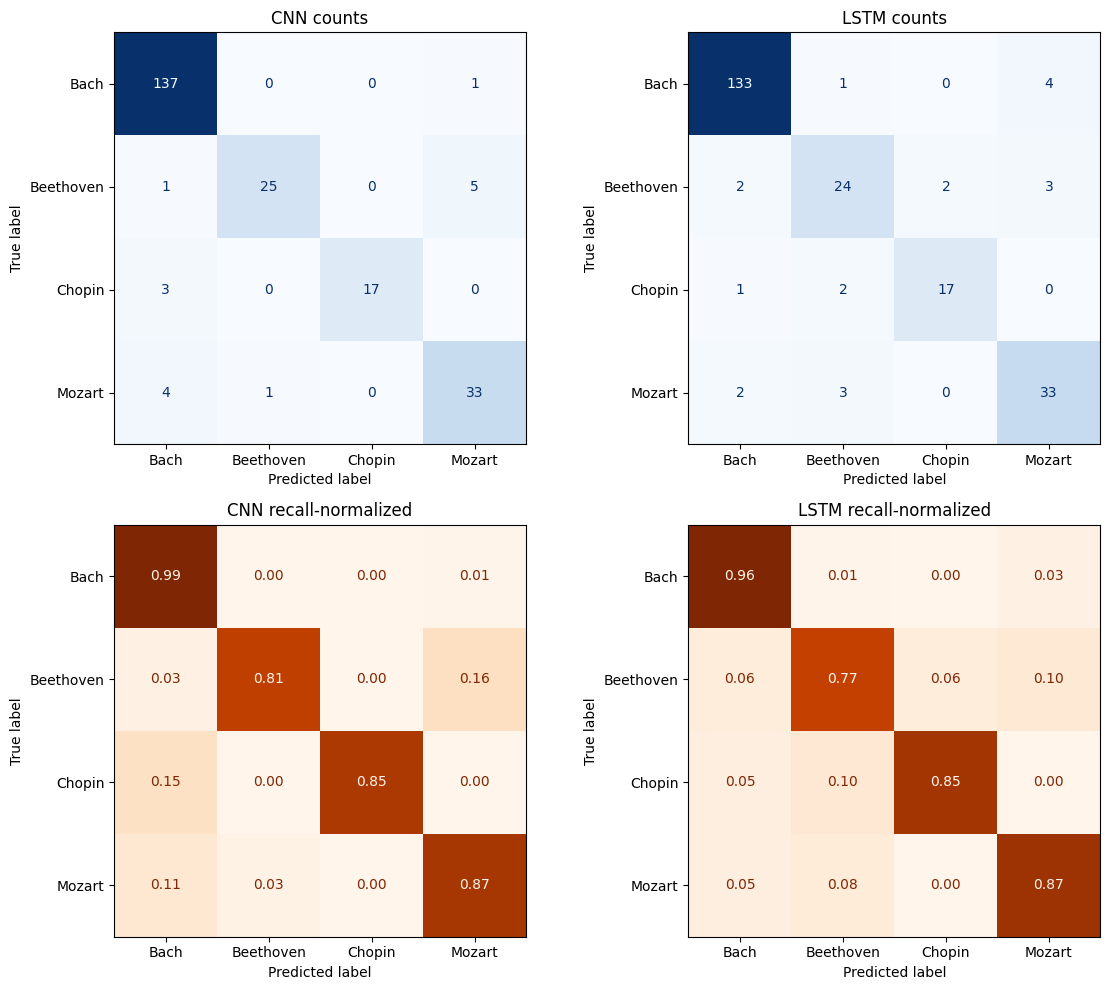

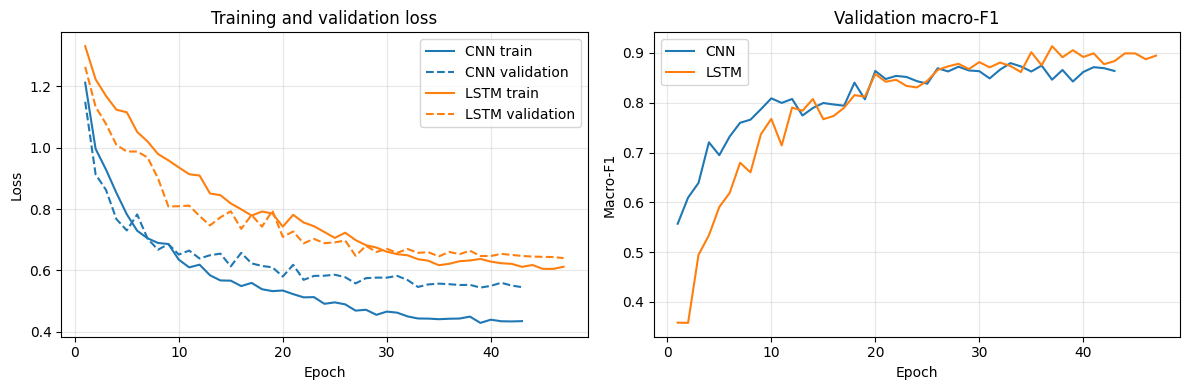

In [31]:
# Compare CNN and LSTM using exactly one source-level prediction per MIDI file.
# Macro-F1 is the checkpoint-selection metric; accuracy and AUC are secondary.

label_indices = np.arange(NUM_CLASSES)
summary_rows = []
per_class_rows = []

for model_name, metrics in test_results.items():
    source_count = len(metrics["source_ids"])
    expected_sources = test_df["source_id"].nunique()
    if source_count != expected_sources:
        raise AssertionError(
            f"{model_name} has {source_count} predictions, expected {expected_sources} sources."
        )

    output_dir = SEPARATE_MODEL_DIR / model_name.lower()
    predictions_df = pd.DataFrame(
        {
            "source_id": metrics["source_ids"],
            "chunk_count": metrics["chunk_counts"],
            "true_label_index": metrics["targets"],
            "pred_label_index": metrics["predictions"],
            "true_composer": [index_to_label[index] for index in metrics["targets"]],
            "pred_composer": [index_to_label[index] for index in metrics["predictions"]],
        }
    )
    for class_index, composer in index_to_label.items():
        predictions_df[f"prob_{composer}"] = metrics["probabilities"][:, class_index]
    predictions_df.to_csv(output_dir / "test_predictions.csv", index=False)

    summary_rows.append(
        {
            "model": model_name,
            "parameters": sum(
                parameter.numel() for parameter in trained_models[model_name].parameters()
            ),
            "selected_epoch": validation_summaries[model_name]["best_epoch"],
            "validation_macro_f1": validation_summaries[model_name]["best_val_macro_f1"],
            "test_accuracy": metrics["accuracy"],
            "test_macro_f1": metrics["macro_f1"],
            "test_macro_auc_ovr": metrics["macro_auc_ovr"],
            "minimum_class_f1": metrics["min_class_f1"],
            "minimum_class_recall": metrics["min_class_recall"],
            "test_sources": source_count,
            "mean_chunks_per_source": metrics["chunk_counts"].mean(),
            "max_chunks_per_source": metrics["chunk_counts"].max(),
        }
    )

    for class_index, composer in index_to_label.items():
        per_class_rows.append(
            {
                "model": model_name,
                "composer": composer,
                "precision": metrics["precision_by_class"][class_index],
                "recall": metrics["recall_by_class"][class_index],
                "f1": metrics["f1_by_class"][class_index],
                "support": metrics["support_by_class"][class_index],
            }
        )

    print("\n" + "=" * 72)
    print(f"{model_name} TEST CLASSIFICATION REPORT (SOURCE LEVEL)")
    print("=" * 72)
    print(
        classification_report(
            metrics["targets"],
            metrics["predictions"],
            labels=label_indices,
            target_names=composer_names,
            digits=4,
            zero_division=0,
        )
    )

experiment_summary = pd.DataFrame(summary_rows).sort_values(
    "validation_macro_f1",
    ascending=False,
)
per_class_summary = pd.DataFrame(per_class_rows).sort_values(["model", "composer"])
experiment_summary.to_csv(SEPARATE_MODEL_DIR / "experiment_summary.csv", index=False)
per_class_summary.to_csv(SEPARATE_MODEL_DIR / "per_class_test_metrics.csv", index=False)

print("\nExperiment summary:")
display(experiment_summary.round(4))
print("\nPer-class source-level metrics:")
display(per_class_summary.round(4))
print()

model_items = list(test_results.items())
fig, axes = plt.subplots(2, len(model_items), figsize=(6 * len(model_items), 10))
axes = np.asarray(axes).reshape(2, -1)
for column, (model_name, metrics) in enumerate(model_items):
    count_matrix = confusion_matrix(
        metrics["targets"],
        metrics["predictions"],
        labels=label_indices,
    )
    normalized_matrix = confusion_matrix(
        metrics["targets"],
        metrics["predictions"],
        labels=label_indices,
        normalize="true",
    )

    ConfusionMatrixDisplay(
        confusion_matrix=count_matrix,
        display_labels=composer_names,
    ).plot(ax=axes[0, column], cmap=plt.cm.Blues, colorbar=False, values_format="d")
    axes[0, column].set_title(f"{model_name} counts")
    print()

    ConfusionMatrixDisplay(
        confusion_matrix=normalized_matrix,
        display_labels=composer_names,
    ).plot(ax=axes[1, column], cmap=plt.cm.Oranges, colorbar=False, values_format=".2f")
    axes[1, column].set_title(f"{model_name} recall-normalized")

plt.tight_layout()
plt.savefig(SEPARATE_MODEL_DIR / "confusion_matrices_source_level.png", dpi=150)
plt.show()
print()

# Training curves, including the macro-F1 used for checkpoint selection.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, history in training_histories.items():
    color = "tab:blue" if model_name == "CNN" else "tab:orange"
    axes[0].plot(history["epoch"], history["train_loss"], color=color, label=f"{model_name} train")
    axes[0].plot(
        history["epoch"],
        history["val_loss"],
        color=color,
        linestyle="--",
        label=f"{model_name} validation",
    )
    axes[1].plot(history["epoch"], history["val_macro_f1"], color=color, label=model_name)

axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SEPARATE_MODEL_DIR / "training_comparison.png", dpi=150)
plt.show()